In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("loan_data.csv")

In [4]:
df.head()

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732,19210,44.13,employed,Approved


In [5]:
df.shape

(24000, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Text               24000 non-null  object 
 1   Income             24000 non-null  int64  
 2   Credit_Score       24000 non-null  int64  
 3   Loan_Amount        24000 non-null  int64  
 4   DTI_Ratio          24000 non-null  float64
 5   Employment_Status  24000 non-null  object 
 6   Approval           24000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 1.3+ MB


In [7]:
df.describe()

,Income,Credit_Score,Loan_Amount,DTI_Ratio
count,24000.000000,24000.000000,24000.000000,24000.000000
mean,110377.552708,575.720333,44356.154833,34.719167
std,51729.677627,159.227621,34666.604785,32.322471
min,20001.000000,300.000000,1005.000000,2.530000
25%,65635.750000,437.000000,16212.000000,14.507500
50%,110464.000000,575.000000,35207.000000,24.860000
75%,155187.000000,715.000000,65622.750000,41.840000
max,200000.000000,850.000000,158834.000000,246.330000


In [8]:
df.isnull().sum()

Text                 0
Income               0
Credit_Score         0
Loan_Amount          0
DTI_Ratio            0
Employment_Status    0
Approval             0
dtype: int64

In [9]:
df.duplicated().sum()

0

# Eda

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le = LabelEncoder()

In [13]:
categ_cols = df.select_dtypes(include=['object'])

In [14]:
categ_cols

,Text,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,employed,Rejected
1,I want to make home improvements like installi...,employed,Rejected
2,"I need a loan for home renovation, including a...",employed,Rejected
3,I need funds to buy new furniture and applianc...,unemployed,Rejected
4,I need a loan to start a small business.,employed,Approved
...,...,...,...
23995,I need funds to pay for my daughter's college ...,employed,Approved
23996,I need financial assistance to launch my own Y...,employed,Rejected
23997,I need money to open a small bookstore and café.,employed,Rejected
23998,I want to buy a car for my rideshare business ...,unemployed,Rejected


In [15]:
for col in categ_cols:
     df[col + '_encoded'] = le.fit_transform(df[col])

In [16]:
df['Approval_encoded'].value_counts()

Approval_encoded
1    20067
0     3933
Name: count, dtype: int64

In [17]:
df['Text_encoded'].unique()

array([14, 64,  0, 35, 20, 19, 26, 51, 10,  5, 13, 56, 69, 65, 15, 33, 52,
       28, 61, 60, 21, 54, 16,  4, 18, 41, 50, 12, 17, 42, 55, 57, 37, 36,
       40, 30, 38,  9, 27, 66, 43,  6,  2, 48, 53,  7, 67, 63, 24, 11, 49,
       58, 59, 32,  3, 23, 47,  1, 34, 25, 22,  8, 39, 29, 62, 68, 46, 45,
       44, 31])

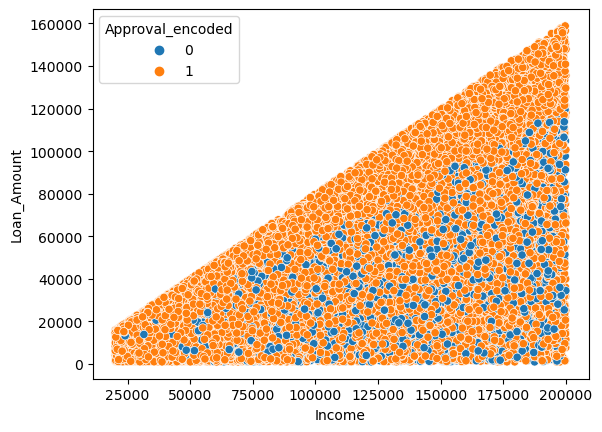

In [18]:
sns.scatterplot(data=df, x='Income', y='Loan_Amount', hue='Approval_encoded')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

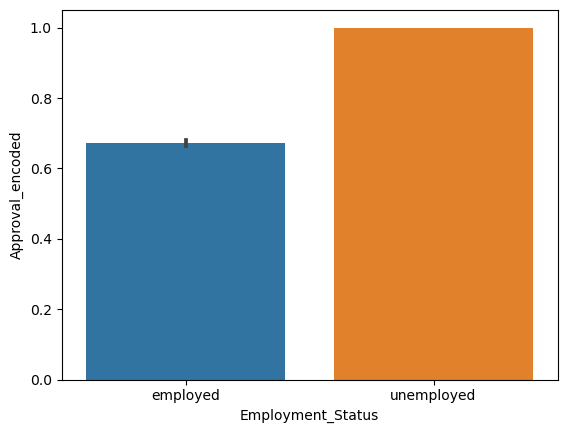

In [19]:
sns.barplot(data=df, x='Employment_Status', y='Approval_encoded')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

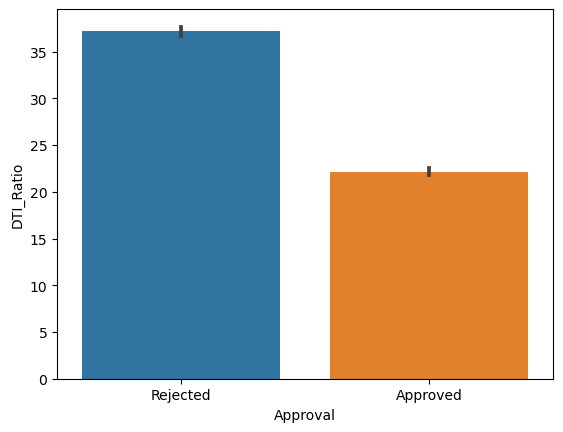

In [20]:
sns.barplot(data=df, x='Approval', y='DTI_Ratio')
plt.show

# ML ALGORITHM

In [22]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

In [23]:
X = df.drop(['Text','Employment_Status','Approval','Approval_encoded'], axis=1)
y = df['Approval_encoded']

In [24]:
ru = RandomUnderSampler()
ru_X , ru_y = ru.fit_resample(X, y)

In [25]:
ru_y.value_counts()

Approval_encoded
0    3933
1    3933
Name: count, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [27]:
X_train, X_test, y_train, y_test = train_test_split(ru_X, ru_y, test_size = 0.2, random_state = 42)

In [28]:
lr = LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [29]:
y_pred = lr.predict(X_test)

In [30]:
print("Accuracy :", accuracy_score(y_test,y_pred)*100)

Accuracy : 75.5400254129606


In [31]:
lr.predict([[61853,732,19210,44.13,20,0]])

C:\Users\Ravi\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [32]:
X

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Text_encoded,Employment_Status_encoded
0,26556,581,8314,79.26,14,0
1,197392,389,111604,22.14,64,0
2,44561,523,34118,45.44,0,0
3,190363,729,118757,10.22,35,1
4,61853,732,19210,44.13,20,0
...,...,...,...,...,...,...
23995,195242,817,16403,24.32,39,0
23996,150246,729,101572,9.97,24,0
23997,64571,650,30533,57.35,51,0
23998,115825,418,89837,10.37,59,1


In [33]:
y

0        1
1        1
2        1
3        1
4        0
        ..
23995    0
23996    1
23997    1
23998    1
23999    0
Name: Approval_encoded, Length: 24000, dtype: int32

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred)*100)

Random Forest Accuracy: 98.79288437102922


In [35]:
rf.predict([[26556,581,8314,79.26,14,0]])

C:\Users\Ravi\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [36]:
rf.score(X_train,y_train), rf.score(X_test,y_test)

(1.0, 0.9879288437102922)

In [79]:
from sklearn.metrics import confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test,rf_pred))

Confusion Matrix:
 [[800   2]
 [ 17 755]]


In [81]:
from sklearn.metrics import classification_report 

In [83]:
print("Classification Report:\n", classification_report(y_test,rf_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       802
           1       1.00      0.98      0.99       772

    accuracy                           0.99      1574
   macro avg       0.99      0.99      0.99      1574
weighted avg       0.99      0.99      0.99      1574

